In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_2d import Tile2Symb2dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2Symb2dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: -0.0335 | Max: 0.0203 | Mean: 0.0019 | Std: 0.0161
Min: 0.0424 | Max: 0.1420 | Mean: 0.1024 | Std: 0.0330
Min: 0.0375 | Max: 0.1889 | Mean: 0.1102 | Std: 0.0500
Min: 0.0594 | Max: 0.2199 | Mean: 0.1326 | Std: 0.0492
Min: 0.0315 | Max: 0.2182 | Mean: 0.1174 | Std: 0.0565
Min: 0.0494 | Max: 0.2141 | Mean: 0.1255 | Std: 0.0527
Min: 0.0531 | Max: 0.2398 | Mean: 0.1347 | Std: 0.0559
Min: 0.0483 | Max: 0.2349 | Mean: 0.1351 | Std: 0.0542
Min: 0.0567 | Max: 0.2531 | Mean: 0.1441 | Std: 0.0580


C:\Users\wojte\AppData\Local\Temp\ipykernel_22852\2571842847.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


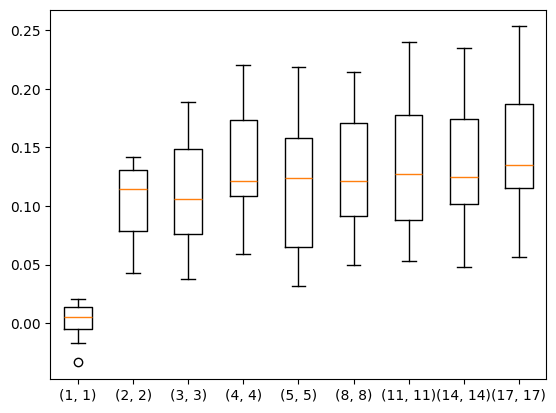

In [2]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0092 | Max: 0.1276 | Mean: 0.0645 | Std: 0.0365
Min: 0.0279 | Max: 0.2135 | Mean: 0.1153 | Std: 0.0533
Min: 0.0792 | Max: 0.2806 | Mean: 0.1588 | Std: 0.0551
Min: 0.0943 | Max: 0.3164 | Mean: 0.1844 | Std: 0.0605
Min: 0.1149 | Max: 0.3304 | Mean: 0.2029 | Std: 0.0626


C:\Users\wojte\AppData\Local\Temp\ipykernel_22852\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


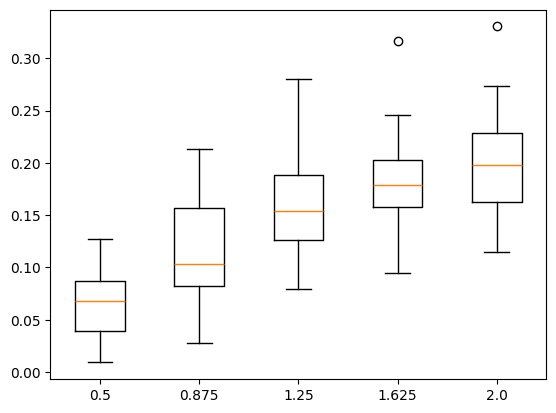

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [5]:
import math
from PIL import Image
from converters.img_converter import ImgConverter
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb2dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, (3, 6), MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------------
 | ~~///||cvjLn<=\|cL}<*>>_;.  | CDMP$NBm@[(]MKH&NMMMMD[NMMl | 
 | ;;;;;;;||>__---._.`         | (JI(l4Dh@})rDC9RM#D5D2l5%r` | 
 | @8NNNNNNNNNNNNNNNNNNNNB8dd( | \~1<jXBQKE[-~''ItS[_=i/|/;_ | 
 | 88NNNNNN0NNNNNNNNNNNNNNB@@( | vnnGGWNWC''~'   =(}]tZ[h[{\ | 
 | @NNNMMR~-_-~YNNNNNNNNNNRW@( | ]]33]h8HNG;     /UGEGGGbD[\ | 
 | 8NNNM$yxEX4y9NNNNNQQHHBW8d) | JzkGAXR@Wd3-    <4SKSXj)Ii- | 
 | OK@N0NNNNNNNNNNNNNNNR8W86X= | |S[2GhUbK@G-    |[GXEDDkG(- | 
 | 0NNNMMMNNNNMMMMMMMNNNW8WU41 | jG3Z3h8W88U_   ;7"'=3F39SU\ | 
 | RNMMMMMMMMMMMMMNNNN00$8DXX\ | ]][{t26V6WD~:_)S>:-:~=]S3L- | 
---------------------------------------------------------------
 | FF92D2T~~~-;|Aa+}<vGkD2T--  |       --:    | 
 | <>|!\\____<<)i!~r~~~'-:`--  | _;;;;;;;;;;_ | 
 | (ii<>>|\><\/|cs+/\/_/____*_ | ]]Z2ZSG[3]][ | 
 | )))(tVlSDE60MMN#DkvedBN0NN/ | 2ZZXF2ZFhZZS | 
 | )i!F>^?SZZliVE]]3SZ]5"'lUT~ | EEXX(li^24EX | 
 | i)))(|_ :`~r(C??=!=|~\_'~   | U4Uh/`` rEh[ | 
 |